# Group 4 Phase 2 Project
### Student name: Monica Wairimu, Jeffrey Gathigi, Jared Mongeri, John Awallah
### Student Pace: Part-time
### Instructor Name: Brianc Chacha and Lians Wanjiku

# Box Office Analysis for Strategic Movie Production
This notebook contains a full end-to-end exploratory data analysis (EDA) combining IMDB and Box Office Mojo data to inform a new movie studio's production strategy.
It includes data loading, cleaning, merging, EDA visualizations, and three concrete business recommendations.

### Objectives of the project
1. **Identify which movie genres generate the highest worldwide revenue in order to guide the studio’s decisions on which types of films to prioritize.**  
2. **Analyze the relationship between IMDB ratings and worldwide box office revenue to understand how audience approval impacts financial performance**  
3. **Examine how movie runtime relates to worldwide revenue to determine the optimal runtime range for commercially successful films**

# 1. Importing Data and Settings

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from difflib import get_close_matches
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

# 2. Unzipping the imdb dataset

In [2]:
import zipfile
with zipfile.ZipFile('./zippedData/im.db.zip', 'r') as z:
    z.extractall('.')

In [3]:
print(os.path.abspath('im.db'))
print(os.path.getsize('im.db'), bytes)

c:\Users\Monic\Downloads\dsc-phase-2-project-v3-main\group_4_project_phase_2\group_4_project_phase_2\im.db
169443328 <class 'bytes'>


# 3. Loading Data
### Data will be loaded from the following;
1. IMDB SQLite database (`im.db`)
2. Box Office Mojo dataset (`bom.movie_gross.csv.gz`)

In [4]:
conn = sqlite3.connect('im.db')

movie_basics = pd.read_sql_query("SELECT * FROM movie_basics", conn)
movie_ratings = pd.read_sql_query("SELECT * FROM movie_ratings", conn)

bom = pd.read_csv('./zippedData/bom.movie_gross.csv.gz') #box office mojo dataset

movie_basics.head(), movie_ratings.head(), bom.head()

(    movie_id                    primary_title              original_title  \
 0  tt0063540                        Sunghursh                   Sunghursh   
 1  tt0066787  One Day Before the Rainy Season             Ashad Ka Ek Din   
 2  tt0069049       The Other Side of the Wind  The Other Side of the Wind   
 3  tt0069204                  Sabse Bada Sukh             Sabse Bada Sukh   
 4  tt0100275         The Wandering Soap Opera       La Telenovela Errante   
 
    start_year  runtime_minutes                genres  
 0        2013            175.0    Action,Crime,Drama  
 1        2019            114.0       Biography,Drama  
 2        2018            122.0                 Drama  
 3        2018              NaN          Comedy,Drama  
 4        2017             80.0  Comedy,Drama,Fantasy  ,
      movie_id  averagerating  numvotes
 0  tt10356526            8.3        31
 1  tt10384606            8.9       559
 2   tt1042974            6.4        20
 3   tt1043726            4.2    

# 4. Exploring the Schema of the Data

In [5]:
#Exploring the Imdb Dataset
# List tables
conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()

[('movie_basics',),
 ('directors',),
 ('known_for',),
 ('movie_akas',),
 ('movie_ratings',),
 ('persons',),
 ('principals',),
 ('writers',)]

In [6]:
# Schema for movie_basics from imdb dataset
conn.execute("PRAGMA table_info(movie_basics);").fetchall()

[(0, 'movie_id', 'TEXT', 0, None, 0),
 (1, 'primary_title', 'TEXT', 0, None, 0),
 (2, 'original_title', 'TEXT', 0, None, 0),
 (3, 'start_year', 'INTEGER', 0, None, 0),
 (4, 'runtime_minutes', 'REAL', 0, None, 0),
 (5, 'genres', 'TEXT', 0, None, 0)]

In [7]:
# Schema for movie_ratings
conn.execute("PRAGMA table_info(movie_ratings);").fetchall()

[(0, 'movie_id', 'TEXT', 0, None, 0),
 (1, 'averagerating', 'REAL', 0, None, 0),
 (2, 'numvotes', 'INTEGER', 0, None, 0)]

In [8]:
#Schema for the bom Data
bom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


# 5. Data Cleaning
This is to ensure there are clean titles to ensure an easy merge
Further, since the bom data is about movies and not tv shows, we have filtered the imdb data to remove items with tv show like characteristic 

In [9]:
# Merge IMDB tables first
imdb = movie_basics.merge(movie_ratings, on='movie_id', how='left')
# Apply movie-like filters
imdb = imdb[
    (imdb['runtime_minutes'] > 40) &
    (imdb['numvotes'] > 1000) &
    (imdb['genres'].notna())
]

len(imdb)
# Clean IMDB titles
imdb['clean_title'] = (
    imdb['primary_title']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
    .str.strip()
)
imdb['clean_title'].head()

2     the other side of the wind
20                     foodfight
32                    dark blood
38                         wazir
39               the wicker tree
Name: clean_title, dtype: object

In [10]:
# Clean BOM titles
bom['clean_title'] = (
    bom['title']
    .str.lower()
    .str.replace(r'\(\d{4}\)', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[^a-z0-9 ]', '', regex=True)
    .str.strip()
)

# 6. Merging of the two datasets

In [11]:
bom_small = bom[['clean_title','domestic_gross','foreign_gross','year']]
merged = imdb.merge(bom_small, on='clean_title', how='left')
merged.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,clean_title,domestic_gross,foreign_gross,year
0,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama,6.9,4517.0,the other side of the wind,NaN,NaN,NaN
1,tt0249516,Foodfight!,Foodfight!,2012,91.0,"Action,Animation,Comedy",1.9,8248.0,foodfight,NaN,NaN,NaN
2,tt0293069,Dark Blood,Dark Blood,2012,86.0,Thriller,6.6,1053.0,dark blood,NaN,NaN,NaN
3,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",7.1,15378.0,wazir,1100000.0,NaN,2016.0
4,tt0323808,The Wicker Tree,The Wicker Tree,2011,96.0,"Drama,Horror",3.9,2328.0,the wicker tree,NaN,NaN,NaN


# 7. Match Rate Diagnostics
This tells how many IMDB movies successfully found revenue data in the BOM dataset after merging

In [12]:
total = len(imdb)
matched = merged['domestic_gross'].notna().sum()
print('Total IMDB titles:', total)
print('Matched titles:', matched)
print('Match rate:', round(matched/total*100,2),'%')

#with a 29.41% match rate we can proceed with the analysis

Total IMDB titles: 9600
Matched titles: 2823
Match rate: 29.41 %


# 8. Exploratory Data Analysis- Top Genres by Avg Worldwide Gross

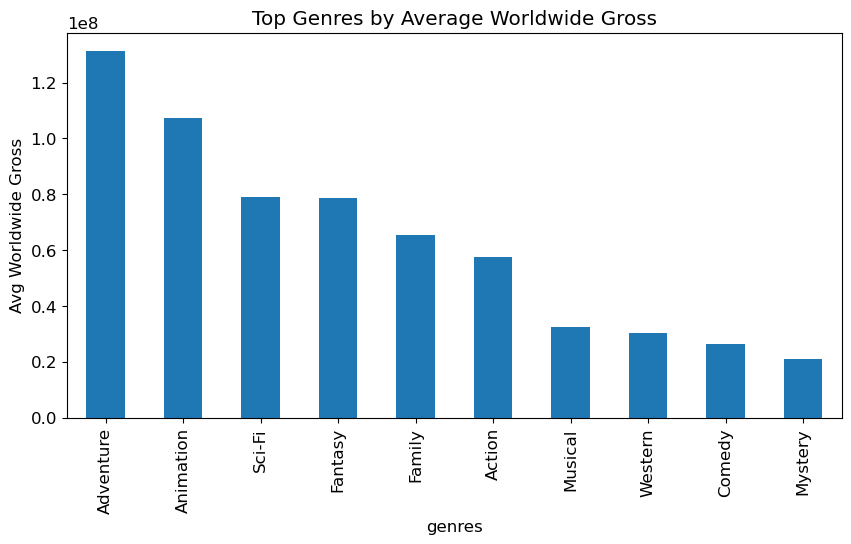

In [ ]:
# Analyze top genres by average worldwide gross

#convert domestic and foreign revenue to numeric values
merged['domestic_gross'] = pd.to_numeric(merged['domestic_gross'], errors='coerce')
merged['foreign_gross'] = pd.to_numeric(merged['foreign_gross'], errors='coerce')

#create worldwide gross
merged['worldwide_gross'] = merged['domestic_gross'].fillna(0) + merged['foreign_gross'].fillna(0)

genre_gross = (
    merged.dropna(subset=['genres'])
        .assign(genres=lambda x: x['genres'].str.split(','))
        .explode('genres')
        .groupby('genres')['worldwide_gross']
        .mean()
        .sort_values(ascending=False)
        .head(10)
)

plt.figure(figsize=(10,5))
genre_gross.plot(kind='bar')
plt.title("Top Genres by Average Worldwide Gross")
plt.ylabel("Avg Worldwide Gross")
plt.show()


# 9. Exploratory Data Analysis — Rating vs Revenue

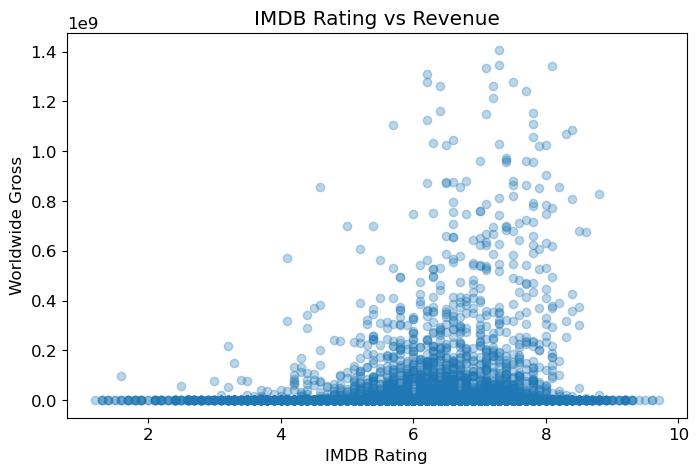

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(merged['averagerating'], merged['worldwide_gross'], alpha=0.3)
plt.xlabel("IMDB Rating")
plt.ylabel("Worldwide Gross")
plt.title("IMDB Rating vs Revenue")
plt.show()

# 10. Exploratory Data Analysis — Runtime vs Worldwide Revenue

In [15]:
# Create runtime bins
bins = [40, 80, 100, 120, 140, 200]
labels = ["40-80", "80-100", "100-120", "120-140", "140-200"]

merged['runtime_bin'] = pd.cut(
    merged['runtime_minutes'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

C:\Users\Monic\AppData\Local\Temp\ipykernel_12728\1486027085.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby('runtime_bin')['worldwide_gross']


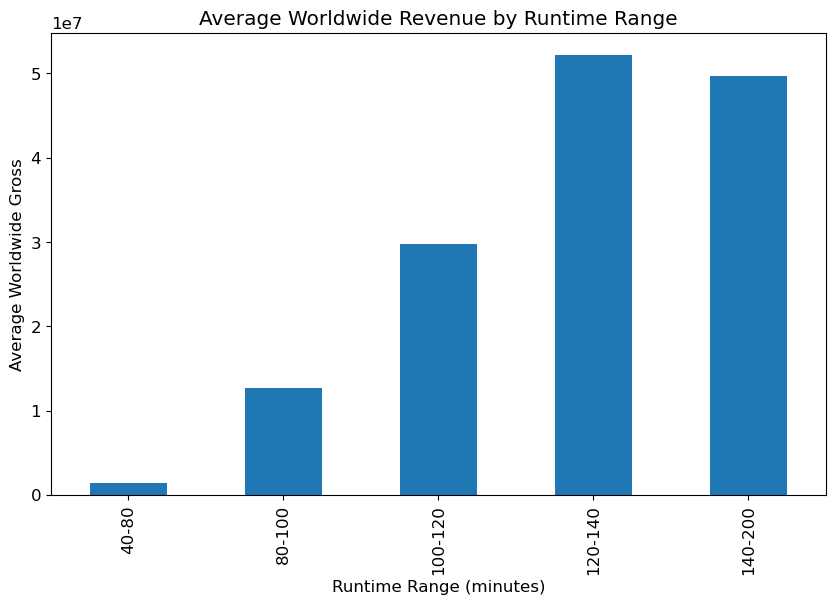

In [16]:
#Group the present a bar graph

runtime_revenue = (
    merged.groupby('runtime_bin')['worldwide_gross']
    .mean()
)

plt.figure(figsize=(10,6))
runtime_revenue.plot(kind='bar')

plt.title("Average Worldwide Revenue by Runtime Range")
plt.xlabel("Runtime Range (minutes)")
plt.ylabel("Average Worldwide Gross")
plt.show()


# Conclusions and Recommendations
1. The studio should focus production investments on Adventure, Animation, and Sci-Fi films, as these genres consistently generate the highest worldwide revenue.
These genres dominate the top-performing films globally and deliver higher financial returns than other genres. Focusing on high-earning genres increases the likelihood of producing commercially successful films capable of competing with major studios.
2. Movies with IMDB ratings in the 6.5–8.0 range tend to produce the strongest and most consistent box-office returns.
While lower-rated films (<6.5) underperform financially, this middle-high rating band shows the best return on investment.
The studio should prioritize developing movies with strong scripts, casting, and production quality aimed at landing within this range.
3. The analysis shows that films with runtimes between roughly 120 and 140 minutes achieve higher average revenue, while very short films tend to underperform. Longer films also show great returns.
This suggests that audiences prefer standard feature-length films and the studio should therefore design productions within this range to increase box-office potential.